In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure1/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
def Barplot(which_var, adata, var='clusters', height=3, color = False):
    plotdata = pd.crosstab(adata.obs[var], adata.obs[which_var], normalize='index') * 100
    if 'category' in plotdata.index.dtype.name:
        plotdata.index.reorder_categories(adata.obs[var].cat.categories[::-1])

    if not color:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False)
    else:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False, color = color)
    ax1.set_title(which_var+' %')
    ax1.set_ylabel(var)
    horiz_offset = 1
    vert_offset = 1.
    ax1 = ax1.legend(bbox_to_anchor = (horiz_offset, vert_offset))
#     ax1.figure.savefig(str(sc.settings.figdir)+'/barplot_'+var+'_proportions_'+which_var+'.pdf', bbox_inches='tight',
#                        dpi=300, orientation='landscape', format= 'pdf', optimize=True)

In [3]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,Homo sapiens


In [5]:
adata_new=sc.read('human_cochlea_annotation_add_40000genes.h5ad')

### FIGURE 1b  
#### cellular map generation

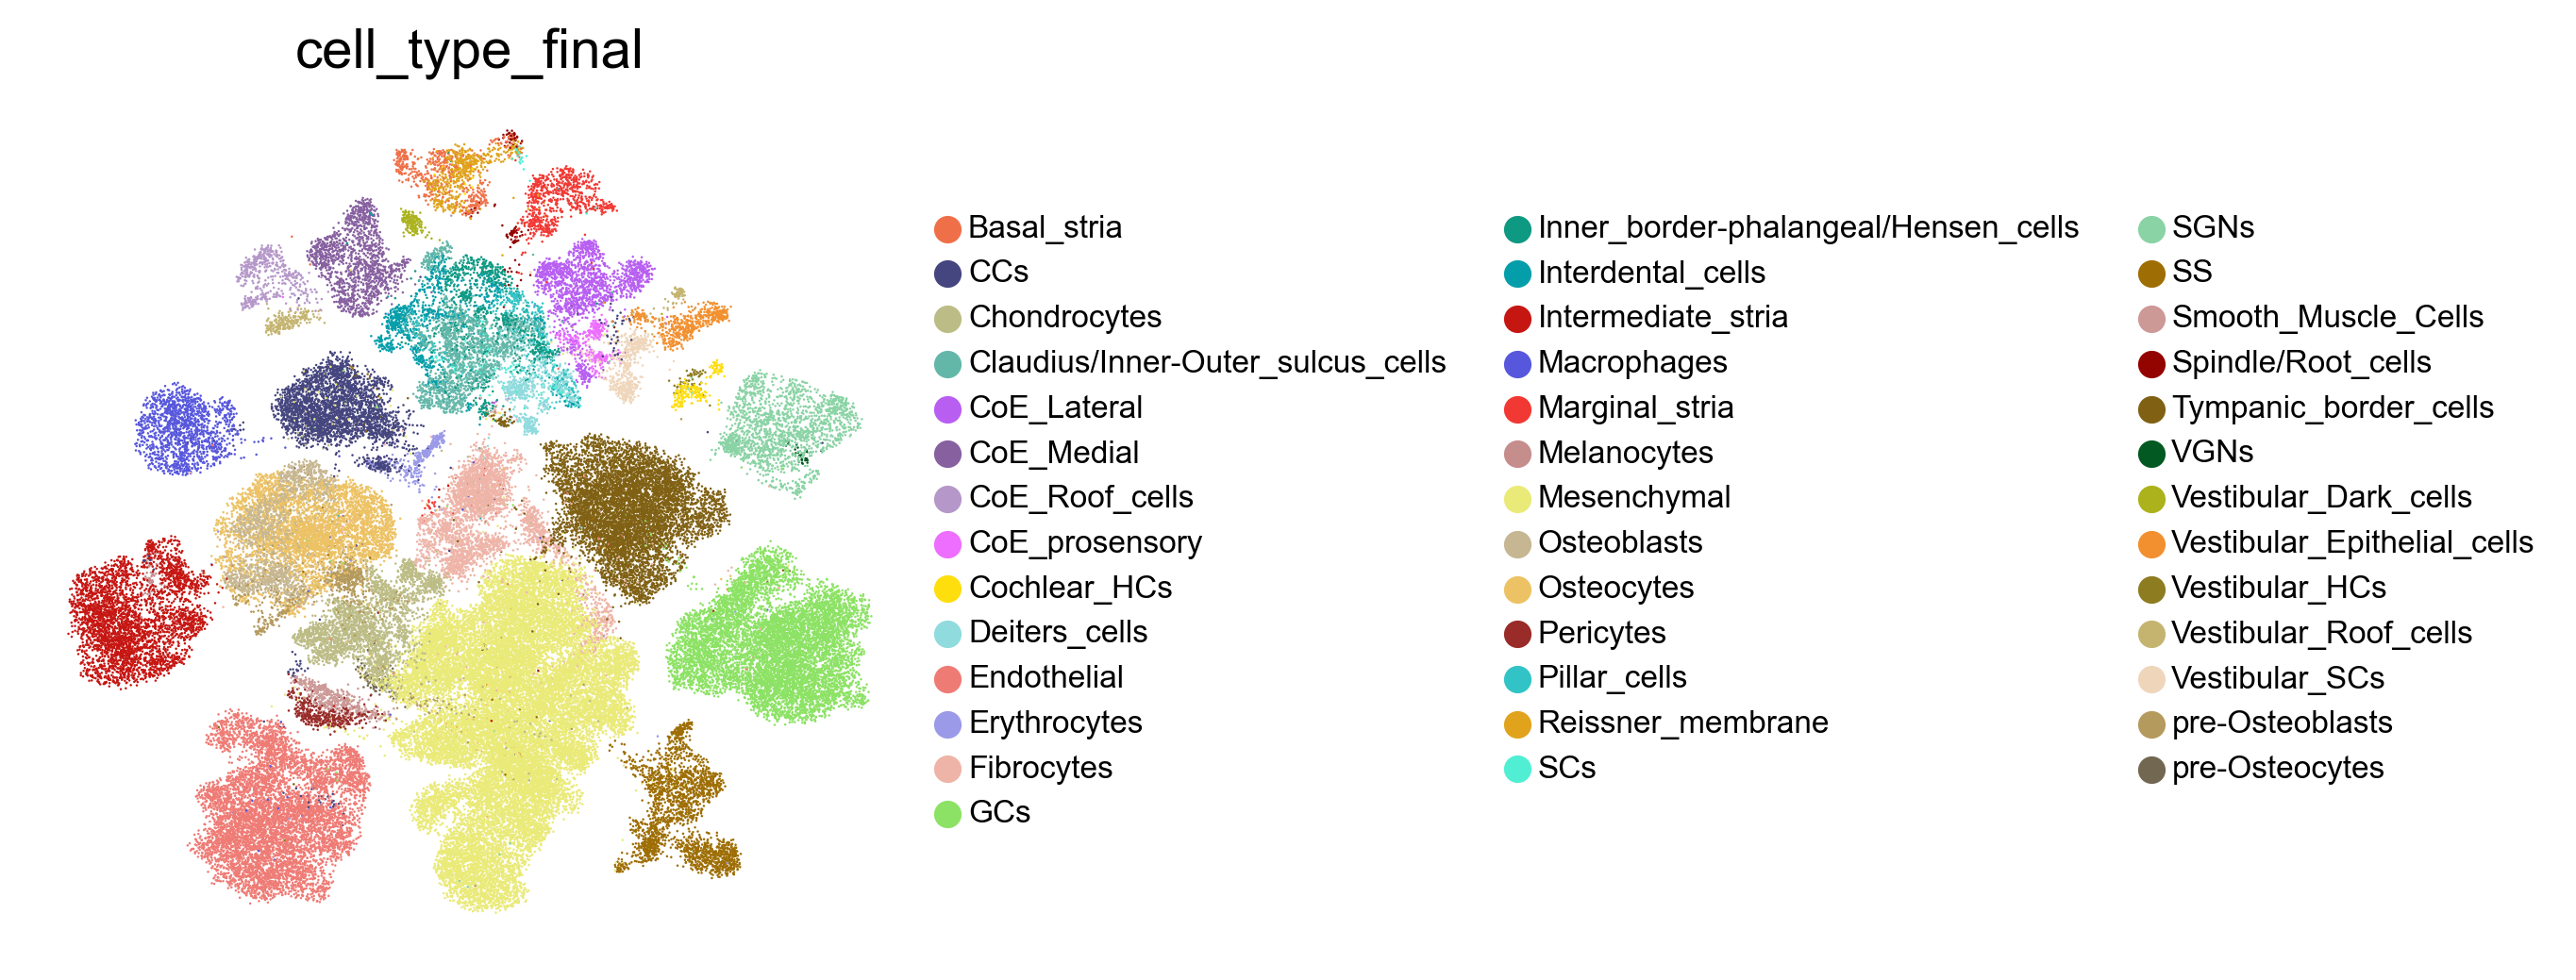

In [7]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_new, color=['cell_type_final'], wspace=0.5,ncols=1,save='_human_prenatal_cochlea_atlas.pdf',
           legend_fontsize=8,) #legend_loc='on data',

#### miloR analysis
#### age bins segragate
#### loom file and obs/var metadata producetion

In [8]:
cut_labels_4 = ['< 12', '< 16','< 20','< 24','< 28', ]
cut_bins = [0, 12, 16,20,24,28 ]

adata_new.obs["age_bins"] = pd.cut(adata_new.obs["gw"], bins=cut_bins, labels=cut_labels_4).astype("str")
adata_new.obs["age_bins"] = pd.Categorical(adata_new.obs["age_bins"], categories=cut_labels_4, ordered=True)
adata_new.obs["age_bins"]

9.5gw_AAACCCAAGCTGCCTG     < 12
9.5gw_AAACCCAAGGCTGTAG     < 12
9.5gw_AAACCCAGTTAGTCGT     < 12
9.5gw_AAACCCATCGGTCATA     < 12
9.5gw_AAACCCATCTACCCAC     < 12
                           ... 
26+3gw_TTTGTTGTCATGGATC    < 28
26+3gw_TTTGTTGTCCGATCGG    < 28
26+3gw_TTTGTTGTCGATGCAT    < 28
26+3gw_TTTGTTGTCGGCTATA    < 28
26+3gw_TTTGTTGTCTCATTTG    < 28
Name: age_bins, Length: 82533, dtype: category
Categories (5, object): ['< 12' < '< 16' < '< 20' < '< 24' < '< 28']

In [9]:
# Convert covariate to continous
adata_new.obs['age_bins'] = adata_new.obs['age_bins'].cat.codes
adata_new.obs['age_bins']
adata_new.obs.groupby(['gw','sample_id','age_bins']).apply(len)

9.5gw_AAACCCAAGCTGCCTG     0
9.5gw_AAACCCAAGGCTGTAG     0
9.5gw_AAACCCAGTTAGTCGT     0
9.5gw_AAACCCATCGGTCATA     0
9.5gw_AAACCCATCTACCCAC     0
                          ..
26+3gw_TTTGTTGTCATGGATC    4
26+3gw_TTTGTTGTCCGATCGG    4
26+3gw_TTTGTTGTCGATGCAT    4
26+3gw_TTTGTTGTCGGCTATA    4
26+3gw_TTTGTTGTCTCATTTG    4
Name: age_bins, Length: 82533, dtype: int8

C:\Users\Dell\AppData\Local\Temp\ipykernel_18760\712163340.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_new.obs.groupby(['gw','sample_id','age_bins']).apply(len)
C:\Users\Dell\AppData\Local\Temp\ipykernel_18760\712163340.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adata_new.obs.groupby(['gw','sample_id','age_bins']).apply(len)


gw  sample_id  age_bins
9   gw9        0            3463
11  gw11       0            3660
14  gw14       1           10504
15  gw15       1            1063
16  gw16       1            6684
17  gw17_1     2            5714
    gw17_2     2            5207
    gw17_3     2            2696
18  gw18       2            8207
20  gw20       2            3343
22  gw22_1     3            4646
    gw22_2     3            6924
23  gw23       3            2840
25  gw25       4           11354
26  gw26       4            6228
dtype: int64

In [ ]:
adata_new.write_loom(data_dir + 'human_cochlea_annotation_REVISION.loom')
adata_new.obs.to_csv(data_dir +'human_cochlea_annotation_obs_REVISION.csv')
adata_new.var.to_csv(data_dir +'human_cochlea_annotation_var_REVISION.csv')

In [ ]:
umap=pd.DataFrame(adata_new.obsm['X_umap']).to_csv(data_dir + 'human_cochlea_annotation_umap_REVISION.csv')
scANVI=pd.DataFrame(adata_new.obsm['X_scANVI']).to_csv(data_dir + 'human_cochlea_annotation_scANVI_REVISION.csv')

### FIGURE 1c  
#### miloR visualization

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
print("="*60)
print("load miloR exported data")
print("="*60)
# ==============================================================
# 1. load adata colors
# ==============================================================
import os
cell_type_colors = adata_new.uns['cell_type_final_colors']
cell_types = adata_new.obs['cell_type_final'].cat.categories.tolist()
color_dict = dict(zip(cell_types, cell_type_colors))

print(f"load {len(color_dict)} cell_type colors")

load miloR exported data
load 40 cell_type colors


In [13]:
# ==============================================================
# 2. read miloR analysized results
# ==============================================================
# read  coordinate DA results
da_results = pd.read_csv(data_dir+"MiloR/REVISION/milo_da_results_with_coords.csv", index_col=0)
print(f"DA results: {da_results.shape}")
# read UMAP coordinate
umap_all = pd.read_csv(data_dir+"MiloR/REVISION/milo_umap_coords_all.csv")
print(f"UMAP all cells: {umap_all.shape}")

DA results: (9290, 12)
UMAP all cells: (82533, 5)


In [15]:
# ==============================================================
# 3. check out datamatrix
# ==============================================================
print("\n" + "="*60)
print("preview")
print("="*60)
print(f"coordinated nhoods: {da_results['X'].notna().sum():,} / {len(da_results):,}")
# mark sig.
da_results['significant'] = da_results['SpatialFDR'] < 0.1
da_results['logFC_color'] = da_results['logFC'].copy()
da_results.loc[~da_results['significant'], 'logFC_color'] = np.nan
print(f"\nsignificant neighbourhoods: {da_results['significant'].sum():,}")
print(f"  Up-regulated (logFC > 0): {(da_results['significant'] & (da_results['logFC'] > 0)).sum():,}")
print(f"  Down-regulated (logFC < 0): {(da_results['significant'] & (da_results['logFC'] < 0)).sum():,}")


preview
coordinated nhoods: 9,290 / 9,290

significant neighbourhoods: 5,592
  Up-regulated (logFC > 0): 2,805
  Down-regulated (logFC < 0): 2,787



plot Neighbourhood Graph


Text(0.5, 0, 'UMAP 1')

Text(0, 0.5, 'UMAP 2')

Text(0.5, 1.0, 'Milo DA - Neighbourhood Graph\n5,592 significant nhoods (FDR < 0.1)')

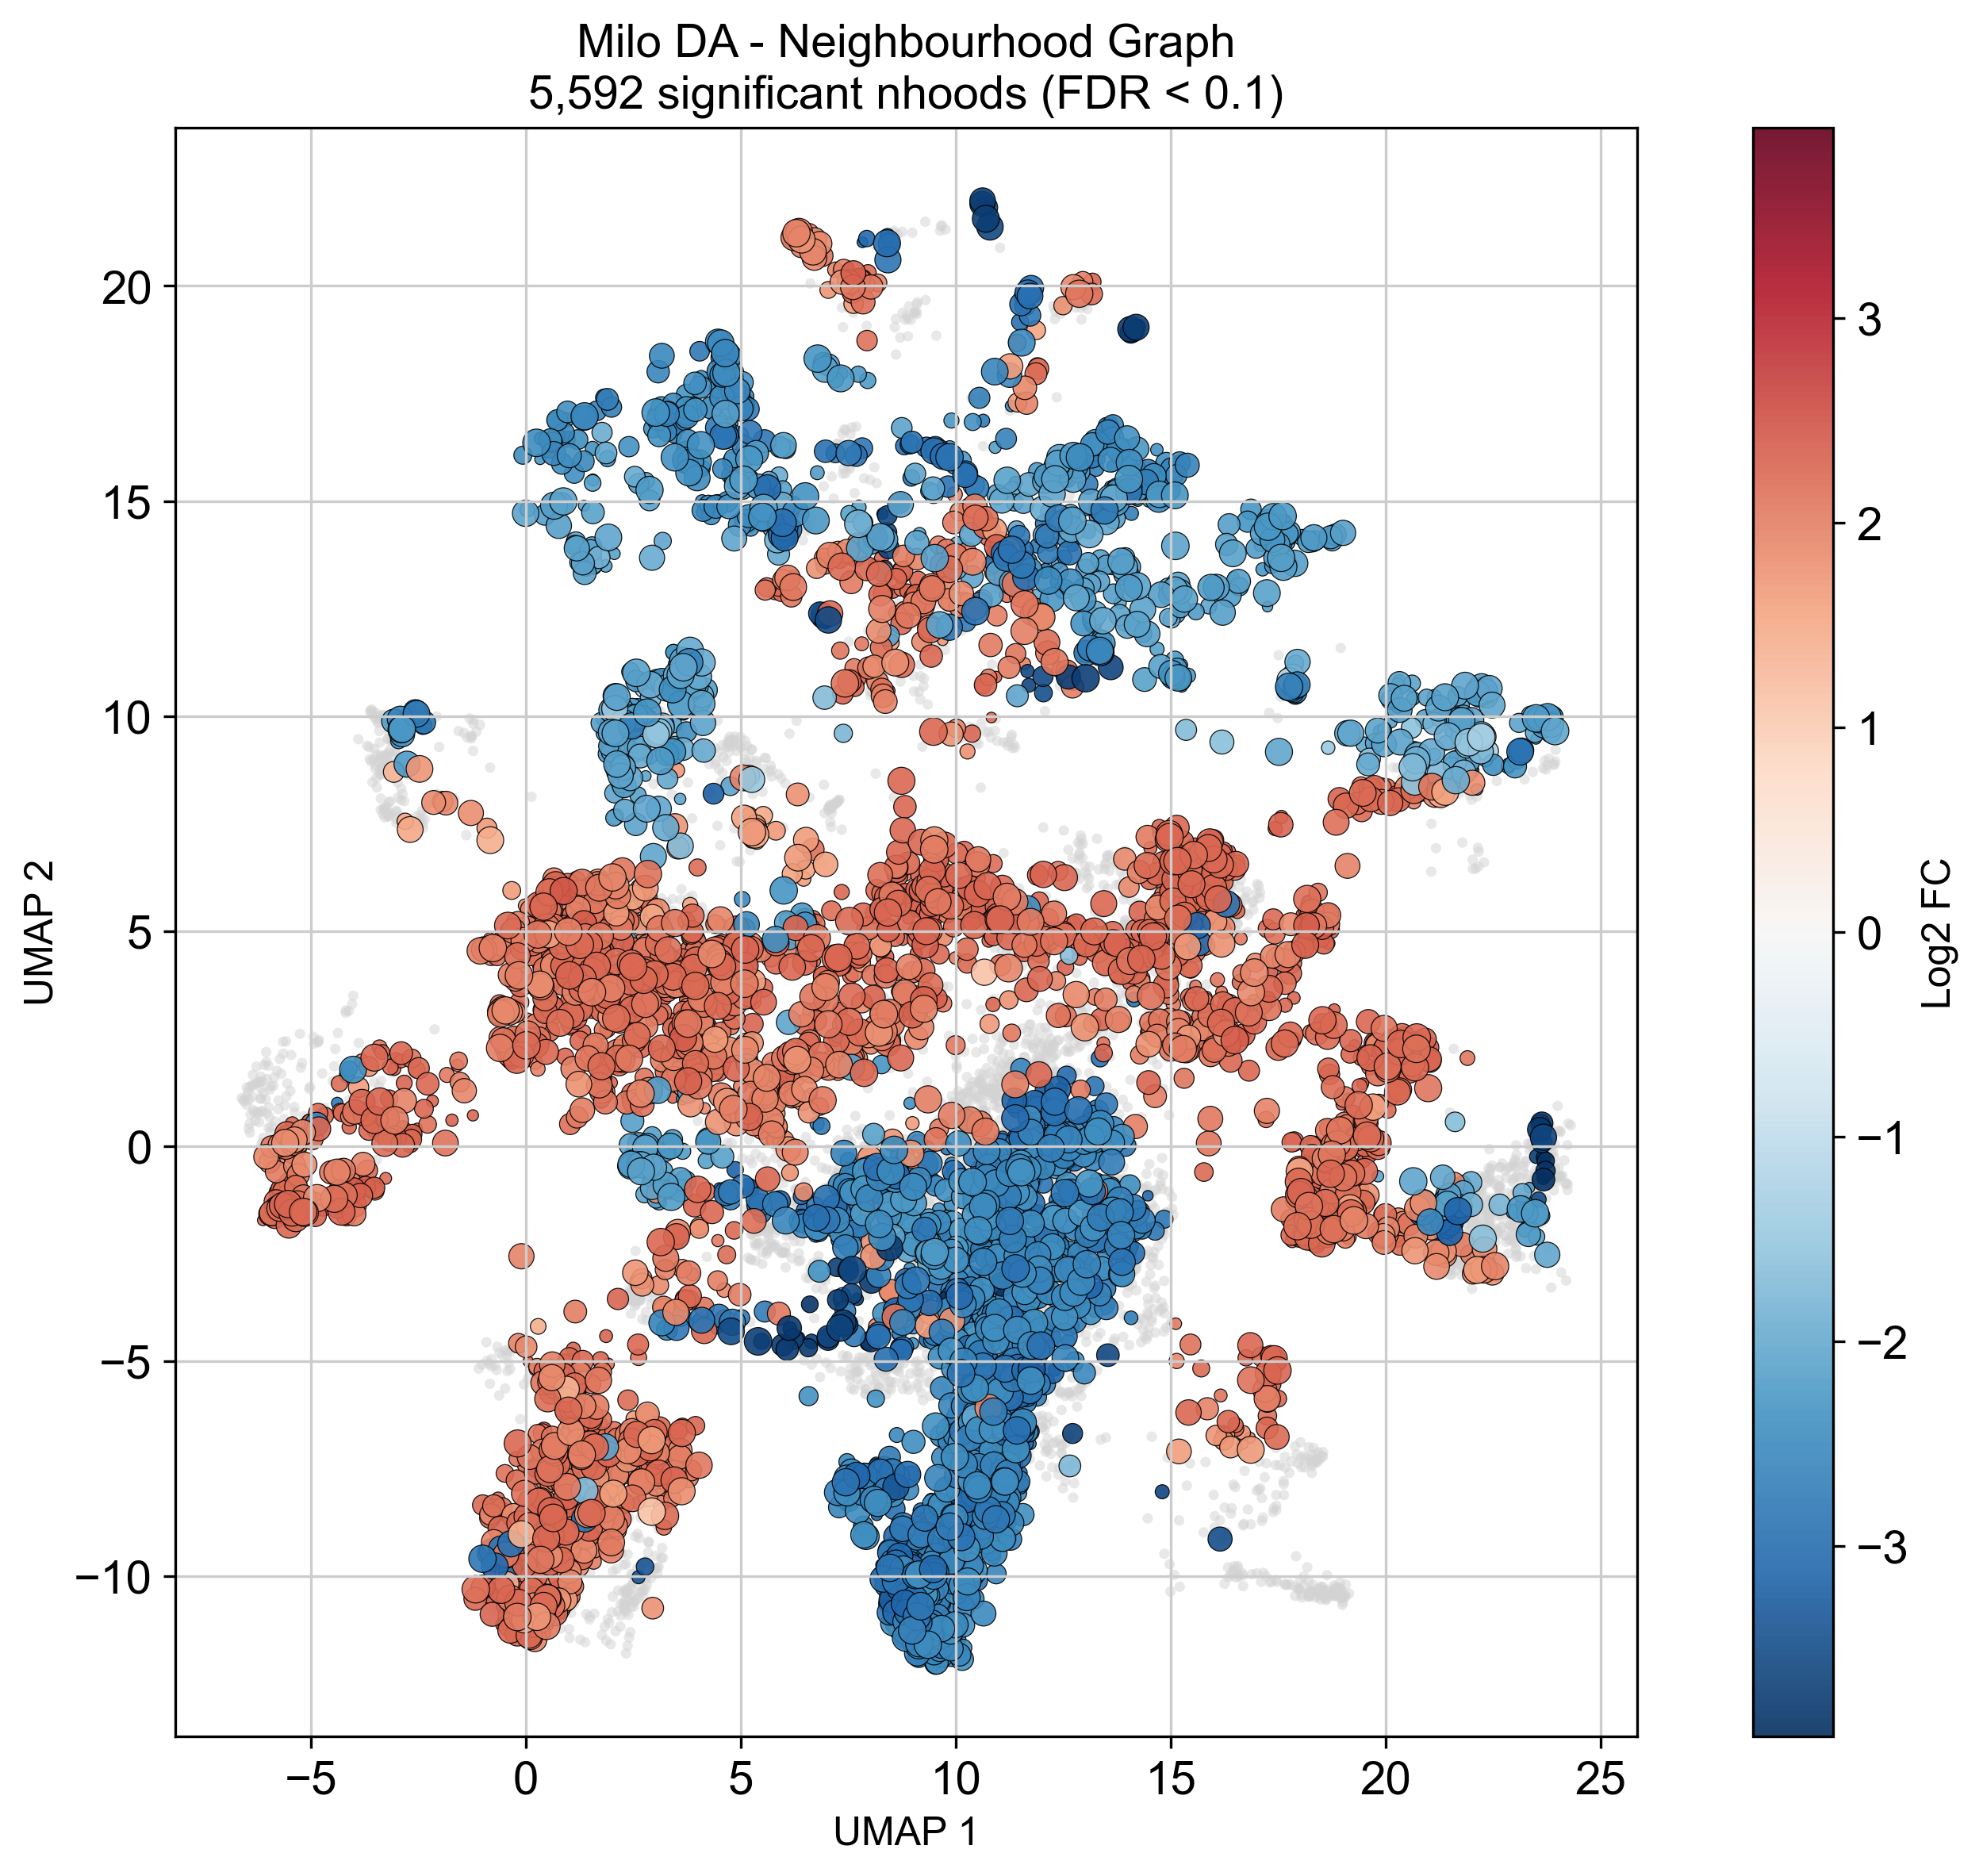

✅ Nhood graph saved: milo_nhood_graph_python.pdf


In [16]:
# ==============================================================
# 4. Neighbourhood Graph
# ==============================================================

print("\n" + "="*60)
print("plot Neighbourhood Graph")
print("="*60)

da_plot = da_results[da_results['X'].notna()].copy()
fig, ax = plt.subplots(figsize=(10, 8))

vmax = max(abs(da_plot['logFC'].max()), abs(da_plot['logFC'].min()))
if vmax == 0:
    vmax = 1

size_norm = (da_plot['Nhood'] - da_plot['Nhood'].min()) / (da_plot['Nhood'].max() - da_plot['Nhood'].min() + 1)
sizes = size_norm * 60 + 10

non_sig_data = da_plot[~da_plot['significant']]
if len(non_sig_data) > 0:
    ax.scatter(non_sig_data['X'], non_sig_data['Y'],
               c='lightgray', s=10, alpha=0.5, edgecolors='none')
plot_data = da_plot[da_plot['significant']]
if len(plot_data) > 0:
    scatter = ax.scatter(plot_data['X'], plot_data['Y'],
                         c=plot_data['logFC'],
                         s=sizes[plot_data.index],
                         cmap='RdBu_r',
                         alpha=0.9,
                         edgecolors='black',
                         linewidth=0.3,
                         vmin=-vmax,
                         vmax=vmax)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Log2 FC', fontsize=12)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title(f'Milo DA - Neighbourhood Graph\n{len(plot_data):,} significant nhoods (FDR < 0.1)', fontsize=14)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(data_dir+'figures/figure1/milo_nhood_graph_python.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Nhood graph saved: milo_nhood_graph_python.pdf")


 Beeswarm Plot based on structures


<Axes: xlabel='logFC', ylabel='cell_type_final'>

[Text(0, 0, 'CoE_Lateral'),
 Text(0, 1, 'CoE_Medial'),
 Text(0, 2, 'CoE_prosensory'),
 Text(0, 3, 'Cochlear_HCs'),
 Text(0, 4, 'SCs'),
 Text(0, 5, 'Pillar_cells'),
 Text(0, 6, 'Deiters_cells'),
 Text(0, 7, 'Inner_border-phalangeal/Hensen_cells'),
 Text(0, 8, 'Interdental_cells'),
 Text(0, 9, 'Claudius/Inner-Outer_sulcus_cells'),
 Text(0, 10, 'Vestibular_Dark_cells'),
 Text(0, 11, 'Vestibular_Roof_cells'),
 Text(0, 12, 'Vestibular_Epithelial_cells'),
 Text(0, 13, 'Vestibular_SCs'),
 Text(0, 14, 'Vestibular_HCs'),
 Text(0, 15, 'SGNs'),
 Text(0, 16, 'VGNs'),
 Text(0, 17, 'GCs'),
 Text(0, 18, 'pre-Osteocytes'),
 Text(0, 19, 'pre-Osteoblasts'),
 Text(0, 20, 'Osteoblasts'),
 Text(0, 21, 'Osteocytes'),
 Text(0, 22, 'SS'),
 Text(0, 23, 'Smooth_Muscle_Cells'),
 Text(0, 24, 'Chondrocytes'),
 Text(0, 25, 'Endothelial'),
 Text(0, 26, 'Pericytes'),
 Text(0, 27, 'CoE_Roof_cells'),
 Text(0, 28, 'Melanocytes'),
 Text(0, 29, 'Basal_stria'),
 Text(0, 30, 'Intermediate_stria'),
 Text(0, 31, 'Marginal_str

Text(5.14744534503441, 0, 'Sensory & Epithelial Compartment')

Text(5.14744534503441, 1, 'Sensory & Epithelial Compartment')

...

Text(5.14744534503441, 38, 'Immune & Other Cells')

Text(5.14744534503441, 39, 'Immune & Other Cells')

Text(0.5, 0, 'Log2 Fold Change')

Text(0, 0.5, 'Cell Type')

Text(0.5, 1.0, 'Milo DA - Beeswarm Plot (FDR < 0.1)')

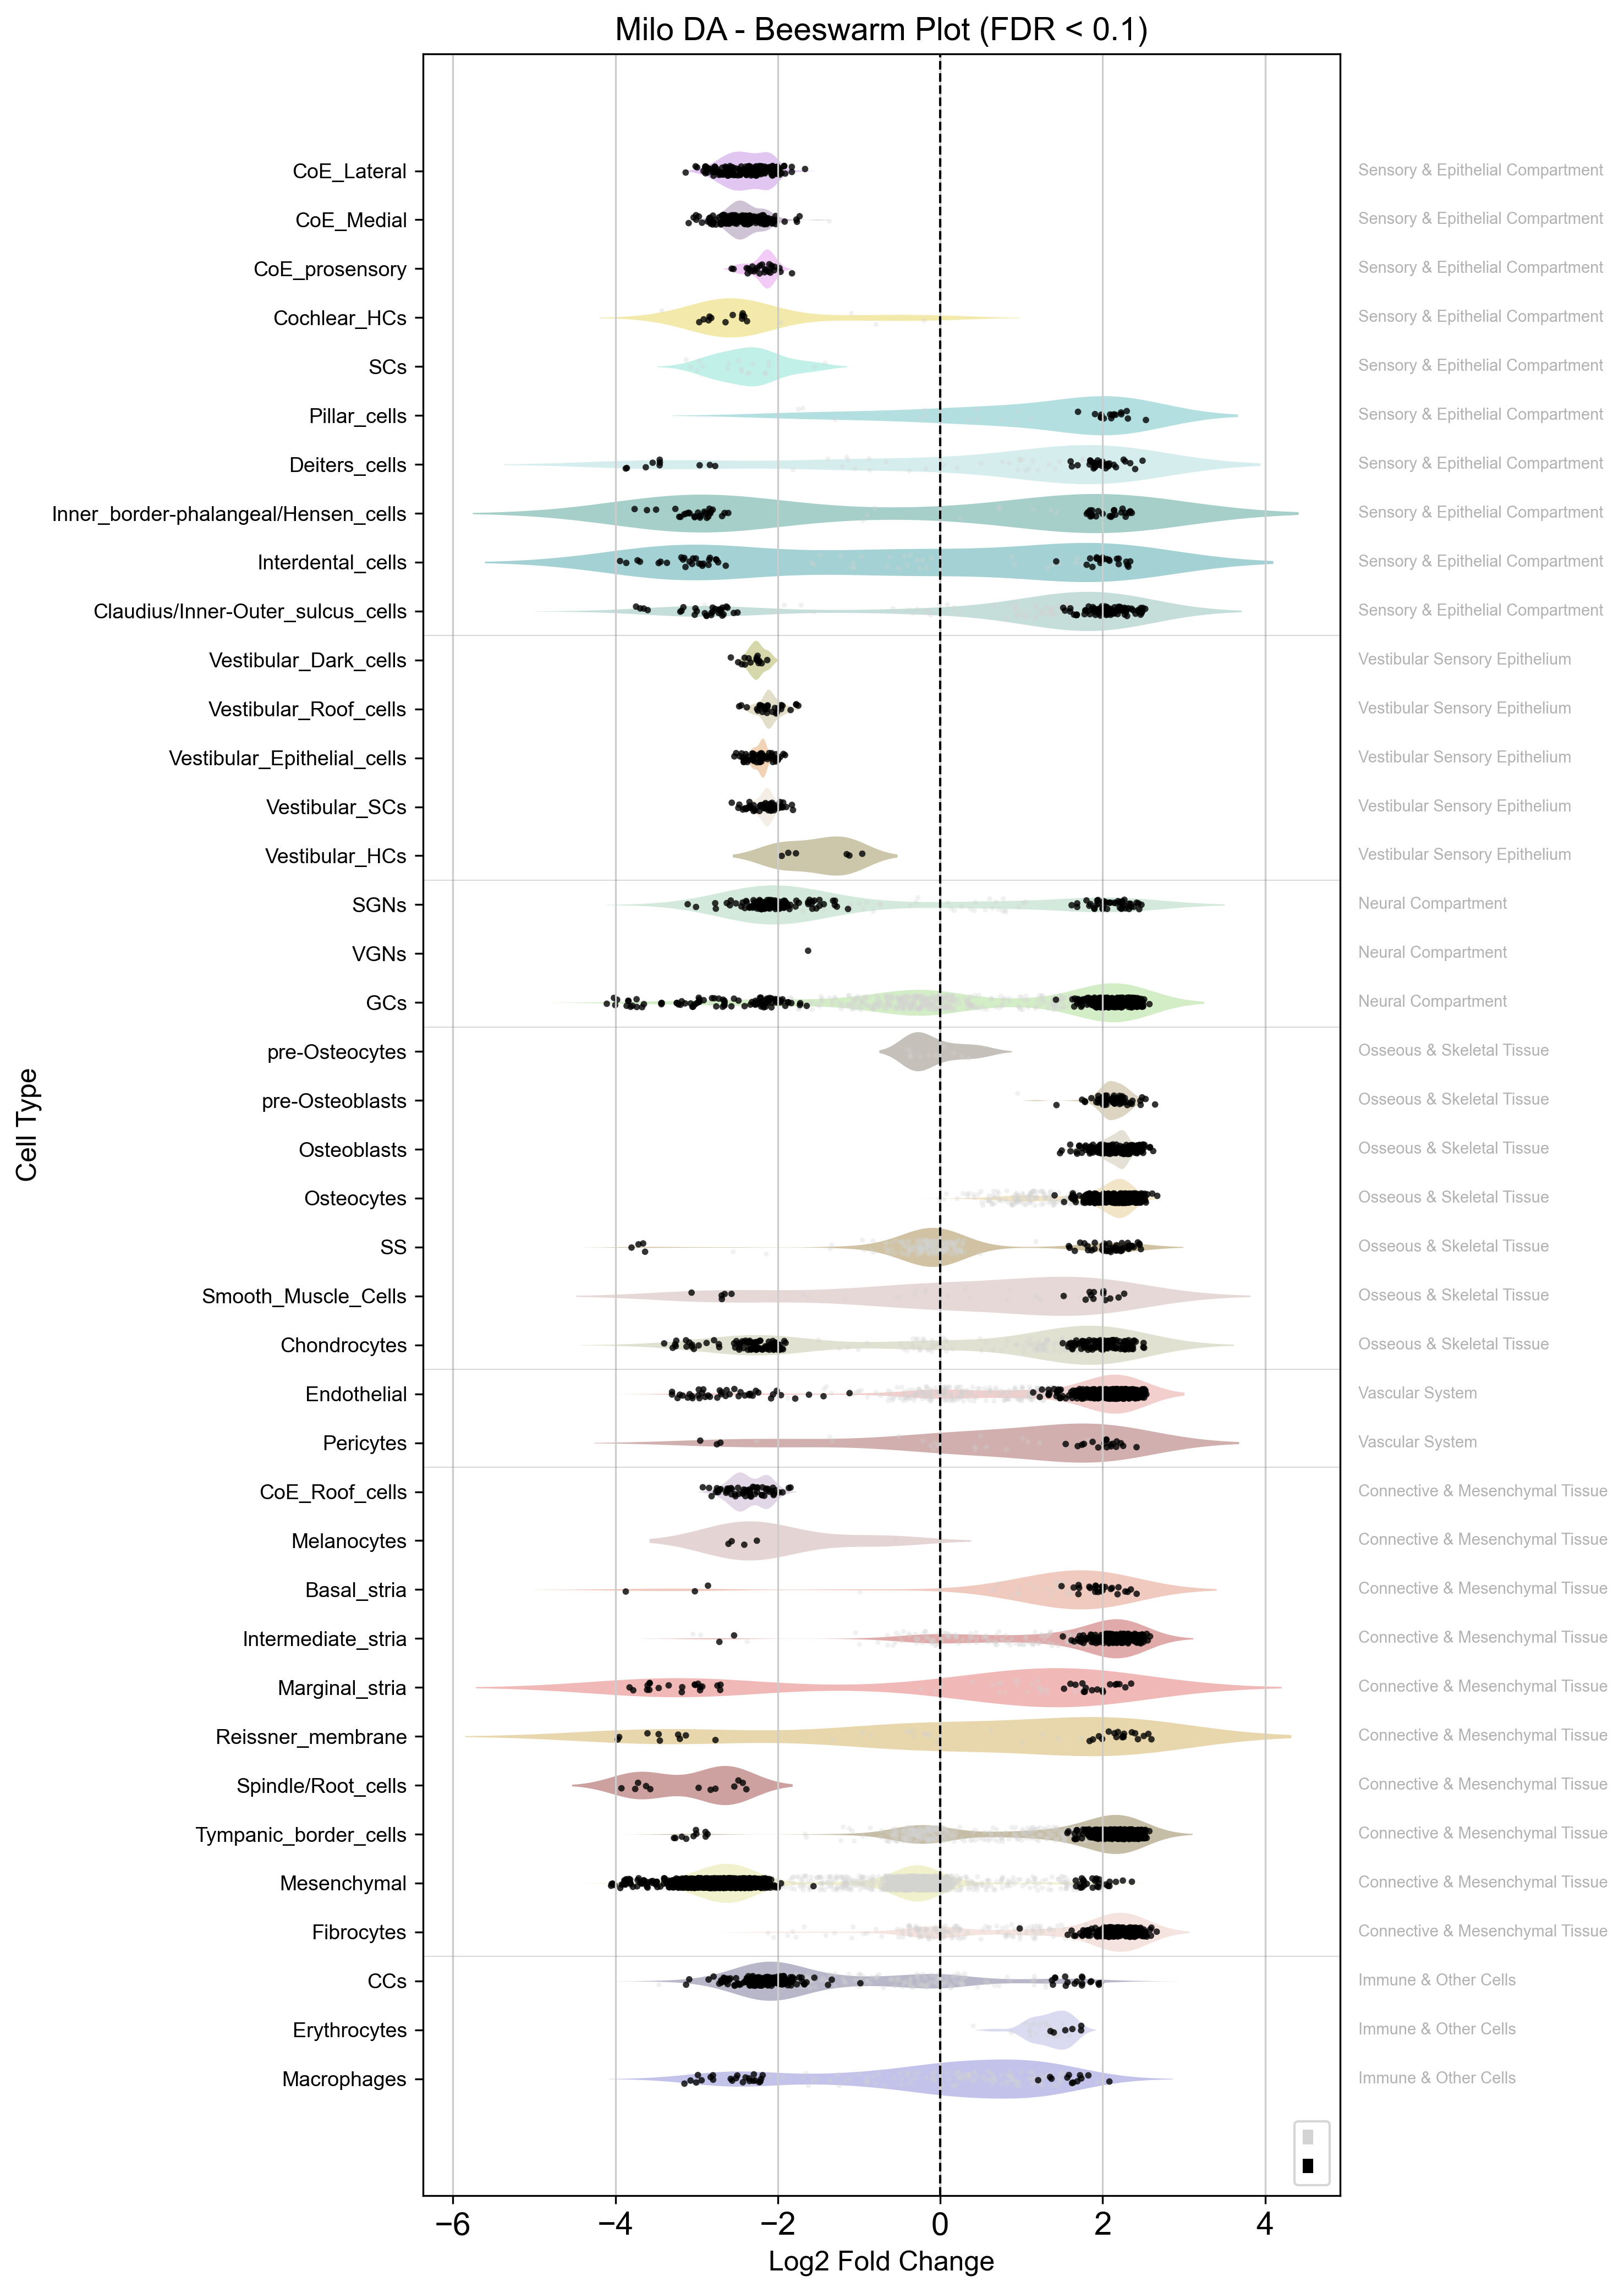

✅ Beeswarm plot saved: milo_beeswarm_grouped_python.pdf


In [20]:
# ==============================================================
# 5.  Beeswarm Plot 
# ==============================================================
print("\n" + "="*60)
print(" Beeswarm Plot based on structures")
print("="*60)

cell_type_groups = {
    'Sensory & Epithelial Compartment': [
        'CoE_Lateral', 
        'CoE_Medial', 
        'CoE_prosensory',
        'Cochlear_HCs', 
        'SCs', 
        'Pillar_cells', 
        'Deiters_cells', 
        'Inner_border-phalangeal/Hensen_cells',
        'Interdental_cells',
        'Claudius/Inner-Outer_sulcus_cells',
    ],
    'Vestibular Sensory Epithelium': [
        'Vestibular_Dark_cells',
        'Vestibular_Roof_cells',
        'Vestibular_Epithelial_cells',
        'Vestibular_SCs',
        'Vestibular_HCs',
        
    ],
    'Neural Compartment': [
        'SGNs', 
        'VGNs',
        'GCs',
    ],
    'Osseous & Skeletal Tissue': [
        'pre-Osteocytes',
        'pre-Osteoblasts', 
        'Osteoblasts', 
        'Osteocytes',
        'SS',
        'Smooth_Muscle_Cells', 
        'Chondrocytes'
    ],
    'Vascular System': [
        'Endothelial', 
        'Pericytes'
    ],
    'Connective & Mesenchymal Tissue': [
        'CoE_Roof_cells',
        'Melanocytes',
        'Basal_stria',
        
        'Intermediate_stria',
        'Marginal_stria',
        'Reissner_membrane',
        'Spindle/Root_cells',
        'Tympanic_border_cells', 
        'Mesenchymal', 
        'Fibrocytes'
    ],
    'Immune & Other Cells': [
        'CCs', 
        'Erythrocytes', 
        'Macrophages'
    ]
}

ordered_cell_types = []
for group_name, cell_types in cell_type_groups.items():
    
    existing_types = [ct for ct in cell_types if ct in da_results['cell_type_final'].values]
    if existing_types:
        ordered_cell_types.extend(existing_types)


unassigned = [ct for ct in da_results['cell_type_final'].unique() if ct not in ordered_cell_types]
if unassigned:
    ordered_cell_types.extend(unassigned)


all_cell_types = da_results['cell_type_final'].unique().tolist()
for ct in all_cell_types:
    if ct not in ordered_cell_types:
        ordered_cell_types.append(ct)

group_labels = {}
for group_name, cell_types in cell_type_groups.items():
    for ct in cell_types:
        if ct in ordered_cell_types:
            group_labels[ct] = group_name

for ct in ordered_cell_types:
    if ct not in group_labels:
        group_labels[ct] = 'Other'


da_results['cell_type_final'] = da_results['cell_type_final'].astype(str)

# 使用定义的顺序
group_order = ordered_cell_types


palette = []
for ct in group_order:
    if ct in color_dict:
        palette.append(color_dict[ct])
    else:
        palette.append('#cccccc')


fig, ax = plt.subplots(figsize=(10, 14))

# Violin plot
sns.violinplot(data=da_results,
               y='cell_type_final',
               x='logFC',
               order=group_order,
               inner=None,
               scale='width',
               alpha=0.4,
               palette=palette,
               linewidth=0,
               ax=ax)


np.random.seed(42)


ns_data = da_results[~da_results['significant']]
if len(ns_data) > 0:
    for i, ct in enumerate(group_order):
        ct_data = ns_data[ns_data['cell_type_final'] == ct]
        if len(ct_data) > 0:
            x_jitter = np.random.uniform(-0.3, 0.3, len(ct_data))
            y_jitter = np.random.uniform(-0.15, 0.15, len(ct_data))
            ax.scatter(ct_data['logFC'] + x_jitter, 
                      [i] * len(ct_data) + y_jitter,
                      c='lightgray', s=5, alpha=0.3, edgecolors='none')


sig_data = da_results[da_results['significant']]
if len(sig_data) > 0:
    for i, ct in enumerate(group_order):
        ct_data = sig_data[sig_data['cell_type_final'] == ct]
        if len(ct_data) > 0:
            x_jitter = np.random.uniform(-0.25, 0.25, len(ct_data))
            y_jitter = np.random.uniform(-0.1, 0.1, len(ct_data))
            ax.scatter(ct_data['logFC'] + x_jitter, 
                      [i] * len(ct_data) + y_jitter,
                      c='black', s=8, alpha=0.8, edgecolors='none')


ax.set_yticks(range(len(group_order)))
ax.set_yticklabels(group_order, fontsize=9)

xlim = ax.get_xlim()
right_pos = xlim[1] + (xlim[1] - xlim[0]) * 0.02

for i, ct in enumerate(group_order):
    if ct in group_labels:
        ax.text(right_pos, i, group_labels[ct], 
                fontsize=7, ha='left', va='center', color='gray', alpha=0.6)

prev_group = None
for i, ct in enumerate(group_order):
    current_group = group_labels.get(ct, 'Other')
    if prev_group is not None and current_group != prev_group:
        ax.axhline(y=i - 0.5, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    prev_group = current_group

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Log2 Fold Change', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.set_title('Milo DA - Beeswarm Plot (FDR < 0.1)', fontsize=14)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgray', edgecolor='none'),
    Patch(facecolor='black', edgecolor='none')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(data_dir+'figures/figure1/milo_beeswarm_grouped_python.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Beeswarm plot saved: milo_beeswarm_grouped_python.pdf")